In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

In [3]:
tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_PUBLICDOTCOM_WSJ_LIVE-QL")),
)

In [5]:
start = datetime.date(2025, 10, 7)
end = datetime.date(2025, 10, 7)

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        FixedRateBondQuery(cusip="CT10", value=FixedRateBondValue.YTM), 
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.RATE)
    ],
    ignore_cache=True
)
df

PRICING USD-SOFR-1D IRSWAPS...: 100%|██████████| 1/1 [00:00<00:00, 63.69it/s]


,FRB,IRS
,CT10 OUTRIGHT YTM,USD-SOFR-1D CT10 OUTRIGHT RATE
Date,,
2025-10-07,4.127839,3.648893


In [7]:
FixedRateBondQuery(cusip="ct2/ct5/ct10", value=FixedRateBondValue.YTM).col_name()

'ct2/ct5/ct10 FLY YTM'

In [13]:
(3.655120 - 4.127839) * 100

-47.27189999999997

In [7]:
IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.RATE).col_name()

CT10
USD-SOFR-1D CT10 OUTRIGHT RATE


'USD-SOFR-1D CT10 OUTRIGHT RATE'

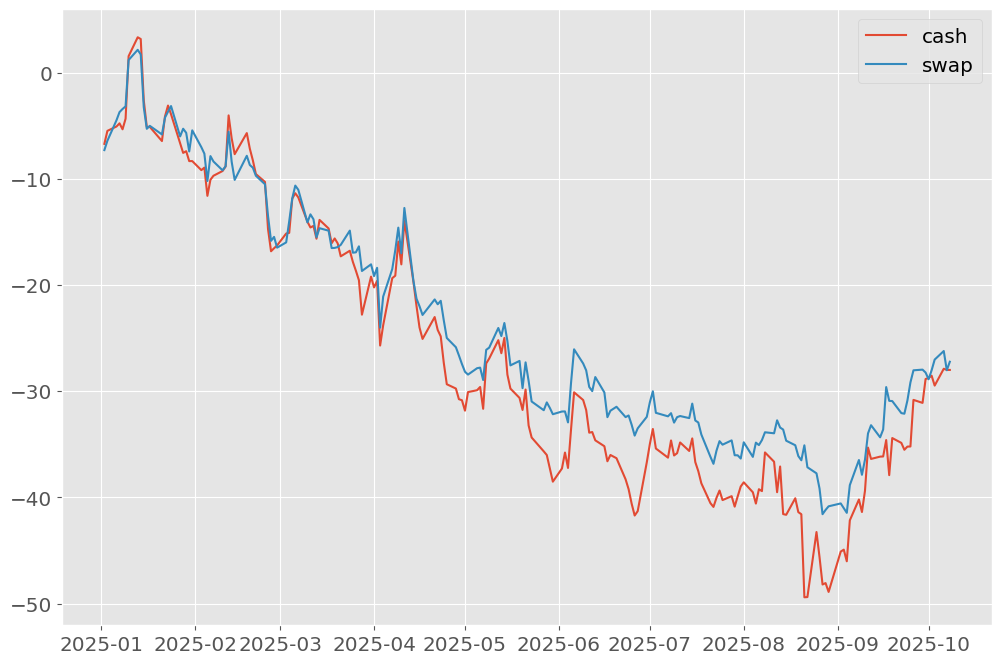

In [9]:
plt.Figure()
plt.plot(df.index, df["FixedRateBond"]["ct2/ct5/ct10 FLY YTM"], label="cash")
plt.plot(df.index, df["IRS"]["USD-SOFR-1D 2Y/5Y/10Y FLY RATE"], label="swap")
plt.legend()
plt.show()